## Data Downloading
In the paper, BraTS 2020 dataset is used for training model only so we only download Training Data and apply futher modification in this dataset. Later, we use BraTS 2019 and 2018 as testing data so we will not adjust any from those.

In [ ]:
import kagglehub

# Download latest version
print("Downloading dataset...")
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

# Read directly from the cached dataset path
DATA_PATH = Path(path)
TRAIN_PATH = DATA_PATH / "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patient_dirs = sorted([d for d in TRAIN_PATH.iterdir() if d.is_dir()])
print(f"Total training cases: {len(patient_dirs)}")
if len(patient_dirs) > 0:
    print(f"Example patient: {patient_dirs[0].name}")


Total training cases: 369
Example patient: BraTS20_Training_001


## EDA & Visualization
Each patient folder contains 5 files:

   *_flair.nii  - Fluid Attenuated Inversion Recovery
   
   *_t1.nii     - T1-weighted
   
   *_t1ce.nii   - T1 contrast-enhanced
   
   *_t2.nii     - T2-weighted
   
   *_seg.nii    - Segmentation mask (ground truth)

In [ ]:
modalities = ["flair","t1","t1ce","t2","seg"]

def get_patient_files(patient_dir):
    """
    return: dict of {modality: filepath} for a patient
    """
    files = {}
    for mod in modalities:
        matches = list(patient_dir.glob(f"*_{mod}.nii*"))
        if matches:
            files[mod] = matches[0]
    return files

sample_files = get_patient_files(patient_dirs[0])
for mod, path in sample_files.items():
    print(f"  {mod:.6s}: {path.name}")

  flair: BraTS20_Training_001_flair.nii
  t1: BraTS20_Training_001_t1.nii
  t1ce: BraTS20_Training_001_t1ce.nii
  t2: BraTS20_Training_001_t2.nii
  seg: BraTS20_Training_001_seg.nii


In [ ]:
import nibabel as nib

def load_volume(filepath):
    """
    Load a NIfTI file
    return: numpy array
    """
    img = nib.load(str(filepath))
    return img.get_fdata()

patient = patient_dirs[0]
files = get_patient_files(patient)

flair = load_volume(files["flair"])
seg = load_volume(files["seg"])

print(f"Volume shape : {flair.shape}")    # (240, 240, 155)
print(f"Voxel dtype  : {flair.dtype}")
print(f"Value range  : [{flair.min():.1f}, {flair.max():.1f}]")

# Segmentation labels:
# 0 = background, 1 = necrotic/non-enhancing tumor core
# 2 = peritumoral edema, 4 = GD-enhancing tumor
print(f"Seg labels   : {np.unique(seg)}")

Volume shape : (240, 240, 155)
Voxel dtype  : float64
Value range  : [0.0, 625.0]
Seg labels   : [0. 1. 2. 4.]


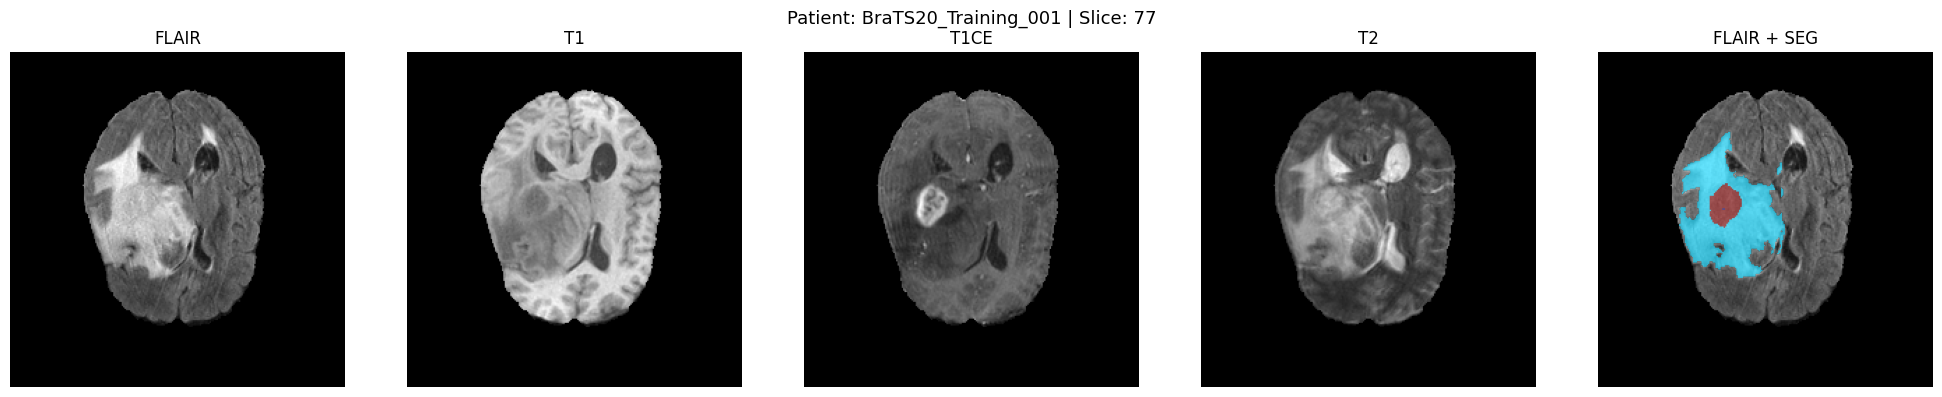

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

##-----------VISUALIZE ALL MODALITIES AT A SINGLE SLICE----------------------------
def visualize_case(patient_dir, slice_idx=None):
    files = get_patient_files(patient_dir)
    volumes = {mod: load_volume(fp) for mod, fp in files.items()}

    H, W, D = volumes["flair"].shape
    if slice_idx is None:
        slice_idx = D // 2

    seg_slice = volumes["seg"][:, :, slice_idx]

    fig, axes = plt.subplots(1,5,figsize=(20,4))
    fig.suptitle(f"Patient: {patient_dir.name} | Slice: {slice_idx}",fontsize=13)

    cmaps = {"flair" : "gray",
             "t1" : "gray",
             "t1ce" : "gray",
             "t2" : "gray"}
    for ax, mod in zip(axes[:4], ["flair","t1","t1ce","t2"]):
        ax.imshow(volumes[mod][:,:,slice_idx].T, cmap="gray", origin="lower")
        ax.set_title(mod.upper())
        ax.axis("off")

    axes[4].imshow(volumes["flair"][:,:,slice_idx].T, cmap="gray", origin="lower")
    seg_overlay = np.ma.masked_where(seg_slice.T == 0, seg_slice.T)
    axes[4].imshow(seg_overlay, cmap="jet", alpha=0.6, origin="lower", vmin=1, vmax=4)
    axes[4].set_title("FLAIR + SEG")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

visualize_case(patient_dirs[0])

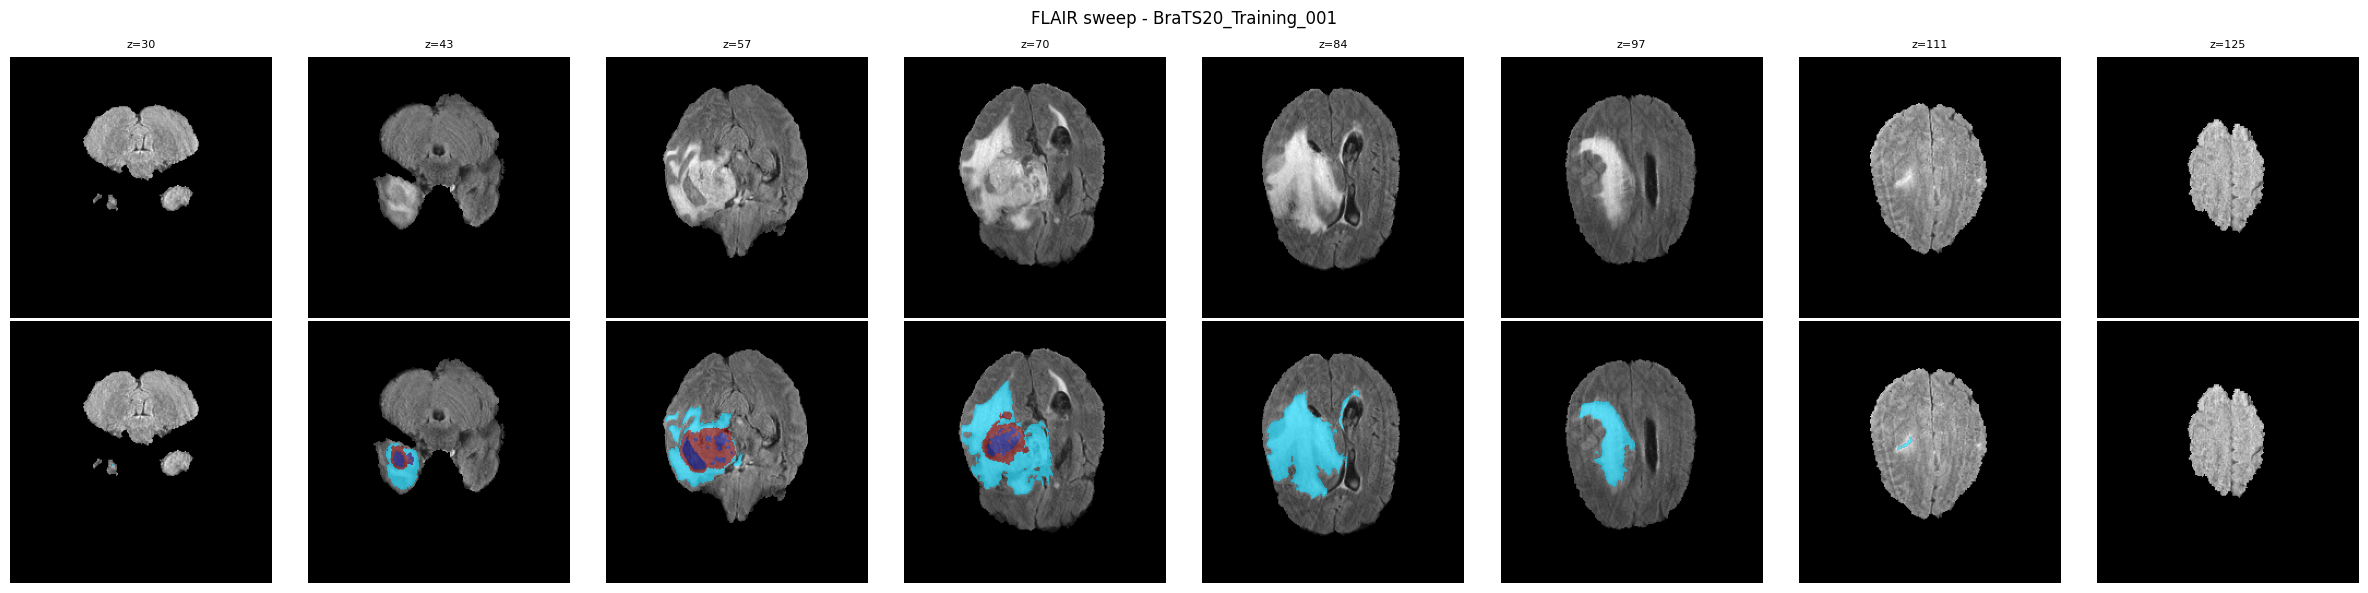

In [ ]:
def visualize_slices(patient_dir,n_slices=8, modality="flair"):
    files = get_patient_files(patient_dir)
    vol = load_volume(files[modality])
    seg = load_volume(files["seg"])
    D = vol.shape[2]

    slice_indices = np.linspace(30,D - 30,n_slices,dtype=int)

    fig, axes = plt.subplots(2,n_slices,figsize=(n_slices*3,6))
    fig.suptitle(f"{modality.upper()} sweep - {patient_dir.name}",fontsize=12)

    for i, sl in enumerate(slice_indices):
        axes[0,i].imshow(vol[:,:,sl].T, cmap="gray", origin="lower")
        axes[0,i].set_title(f"z={sl}",fontsize=8)
        axes[0,i].axis("off")

        seg_sl = np.ma.masked_where(seg[:,:,sl].T == 0, seg[:,:,sl].T)
        axes[1,i].imshow(vol[:,:,sl].T, cmap="gray", origin="lower")
        axes[1,i].imshow(seg_sl, cmap="jet", alpha=0.6, origin="lower",vmin=1,vmax=4)
        axes[1,i].axis("off")

    plt.tight_layout()
    plt.show()
visualize_slices(patient_dirs[0])

## Data Preprocessing
Following the paper, the pipeline for preprocessing is simple and contain no augmentation because deep learning model is well-performed when trained with minimal processed image

Pipeline: Center Crop &rarr;  250 x 250 x 155 to 128 x 128 x 128 &rarr;  3-class masks

In [ ]:
OUTPUT_PATH = Path("./preprocessed")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
TARGET_SHAPE = (128, 128, 128)


In [ ]:
def center_crop(vol, crop_shape):
    """
    Crop 3D volume to crop_shape from the center
    Pads with zseros if volume is smaller than crop_shape on any axis
    """
    res = np.zeros(crop_shape,dtype=vol.dtype)

    src_slices, dst_slices = [], []
    for dim in range(3):
        src_size = vol.shape[dim]
        tgt_size = crop_shape[dim]

        src_start = max((src_size - tgt_size) // 2, 0)
        src_end = src_start + min(tgt_size, src_size)

        dst_start = max((tgt_size - src_size) // 2, 0)
        dst_end = dst_start + (src_end - src_start)

        src_slices.append(slice(src_start, src_end))
        dst_slices.append(slice(dst_start, dst_end))

    res[tuple(dst_slices)] = vol[tuple(src_slices)]
    return res

In [ ]:
from scipy.ndimage import zoom

def reshape_volume(vol, tgt_shape, is_mask=False):
    """
    Reshape using zoom. Nearest-neighbor for masks, trilinear for images
    """
    factors = [t / s for t, s in zip(tgt_shape,vol.shape)]
    order = 0 if is_mask else 1
    return zoom(vol,factors,order=order).astype(vol.dtype)

In [ ]:
def normalize(vol):
    """
    z-score normalization on the brain region (non-zero voxels)
    Keeps background at 0
    """
    mask = vol > 0
    if mask.sum() == 0:
        return vol
    mean = vol[mask].mean()
    std = vol[mask].std()
    out = np.zeros_like(vol,dtype=np.float32)
    out[mask] = (vol[mask] - mean) / (std + 1e-8)
    return out

In [ ]:
def seg_to_multiclass(seg):
    """
    return: (3, H, W, D) binary array [WT, TC, ET]
    """
    wt = (seg > 0).astype(np.uint8)     #Eveything non-BG
    tc = ((seg == 1) | (seg == 4).astype(np.uint8))
    et = (seg == 4).astype(np.uint8)
    return np.stack([wt, tc, et],axis=0)


In [ ]:
def augment_intensity(image, shift_range=(-0.1, 0.1), scale_range=(0.9, 1.1)):
    """
    Apply per-channel random intensity augmentation on brain voxels only.

    Args:
        image : (4, 128, 128, 128) float32 — z-score normalized
        shift_range : additive shift sampled uniformly per channel
        scale_range : multiplicative scale sampled uniformly per channel
    Returns:
        augmented image (4, 128, 128, 128) float32
    """
    augmented = image.copy()

    for ch in range(image.shape[0]):
        brain_mask = augmented[ch] > augmented[ch].min()  # non-background voxels

        shift = np.random.uniform(*shift_range)
        scale = np.random.uniform(*scale_range)

        augmented[ch][brain_mask] = augmented[ch][brain_mask] * scale + shift

    return augmented

In [ ]:
crop_shape = (192, 192, 144)
Mods = ["flair", "t1", "t1ce", "t2"]
def preprocess_patient(patient_dir, save=True, augment=False):
    files = get_patient_files(patient_dir)
    pid   = patient_dir.name

    processed_imgs = {}
    for mod in Mods:
        vol = nib.load(str(files[mod])).get_fdata(dtype=np.float32)
        vol = center_crop(vol, crop_shape)        # 240×240×155 → 192×192×144
        vol = reshape_volume(vol, TARGET_SHAPE)    # → 128×128×128
        vol = normalize(vol)                      # z-score
        processed_imgs[mod] = vol

    image = np.stack([processed_imgs[m] for m in Mods], axis=0)  # (4,128,128,128)

    if augment:
        image = augment_intensity(image)

    seg = nib.load(str(files["seg"])).get_fdata(dtype=np.float32)
    seg = center_crop(seg, crop_shape)
    seg = reshape_volume(seg, TARGET_SHAPE, is_mask=True)
    mask = seg_to_multiclass(seg)                 # (3,128,128,128)

    if save:
        out_dir = Path(OUTPUT_PATH) / pid
        out_dir.mkdir(parents=True, exist_ok=True)
        np.save(out_dir / "image.npy", image)
        np.save(out_dir / "mask.npy",  mask)

    return image, mask


In [ ]:
from tqdm.notebook import tqdm

patient_dirs = sorted([d for d in TRAIN_PATH.iterdir() if d.is_dir()])

failed = []
for patient_dir in tqdm(patient_dirs, desc="Preprocessing"):
    try:
        preprocess_patient(patient_dir, save=True)
    except Exception as e:
        failed.append((patient_dir.name, str(e)))

print(f"\n✅ Done. {len(patient_dirs) - len(failed)}/{len(patient_dirs)} patients processed.")
if failed:
    print("❌ Failed:", failed)

Preprocessing:   0%|          | 0/369 [00:00<?, ?it/s]


✅ Done. 368/369 patients processed.
❌ Failed: [('BraTS20_Training_355', "'seg'")]


In [ ]:
sample_pid = patient_dirs[0].name
img  = np.load(OUTPUT_PATH / sample_pid / "image.npy")
msk  = np.load(OUTPUT_PATH / sample_pid / "mask.npy")

print(f"Image shape : {img.shape}  dtype: {img.dtype}")   # (4, 128, 128, 128) float32
print(f"Mask  shape : {msk.shape}  dtype: {msk.dtype}")   # (3, 128, 128, 128) uint8
print(f"Image range : [{img.min():.2f}, {img.max():.2f}]")
print(f"WT voxels   : {msk[0].sum()}")
print(f"TC voxels   : {msk[1].sum()}")
print(f"ET voxels   : {msk[2].sum()}")

Image shape : (4, 128, 128, 128)  dtype: float32
Mask  shape : (3, 128, 128, 128)  dtype: uint8
Image range : [-3.22, 11.17]
WT voxels   : 83886
TC voxels   : 17097
ET voxels   : 10982


In [ ]:
from pathlib import Path
from typing import Tuple, Optional, Dict, Callable
import torch
from torch.utils.data import Dataset

class ThomasDataset(Dataset):
    """
    PyTorch Dataset for 3D Brain Tumor Segmentation — BraTS 2020.

    Preprocessed structure (per patient):
        <data_path>/
            BraTS20_Training_XXX/
                image.npy  — float32 (4, 128, 128, 128)  [FLAIR,T1,T1CE,T2]
                mask.npy   — float32 (3, 128, 128, 128)  [WT, TC, ET]

    Args:
        data_path  : Path to preprocessed root directory.
        transform  : Optional dict with keys 'image' and 'mask',
                     each a callable applied to the respective tensor.
        augment    : If True, apply per-channel intensity shift/scale at load time.
                     Shift in (−0.1, 0.1), Scale in (0.9, 1.1).
                     Should be True only for training split.
    """

    MODALITIES   = ["FLAIR", "T1", "T1CE", "T2"]
    TARGET_SHAPE = (4, 128, 128, 128)   # expected image shape
    MASK_SHAPE   = (3, 128, 128, 128)   # expected mask  shape  [WT, TC, ET]

    SHIFT_RANGE  = (-0.1, 0.1)
    SCALE_RANGE  = ( 0.9, 1.1)

    def __init__(self, data_path, transform=None, augment= False):
        self.data_path = Path(data_path)
        self.augment   = augment

        if not self.data_path.exists():
            raise FileNotFoundError(f"Data path not found: {self.data_path}")

        # Validate transform dict format
        if transform:
            if not isinstance(transform, dict) or \
               "image" not in transform or "mask" not in transform:
                raise TypeError(
                    "transform must be a dict with 'image' and 'mask' keys."
                )
        self.transform = transform

        # Collect valid patient directories
        self.patient_dirs = sorted([
            d for d in self.data_path.iterdir()
            if d.is_dir()
            and (d / "image.npy").exists()
            and (d / "mask.npy").exists()
        ])

        if len(self.patient_dirs) == 0:
            raise RuntimeError(
                f"No valid patient folders found in {self.data_path}. "
                "Each folder must contain image.npy and mask.npy."
            )

    def __len__(self) -> int:
        return len(self.patient_dirs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            image_tensor : float32 (4, 128, 128, 128)
            mask_tensor  : float32 (3, 128, 128, 128)
        """
        if idx < 0 or idx >= len(self):
            raise IndexError(f"Index {idx} out of range for dataset of size {len(self)}.")

        patient_dir = self.patient_dirs[idx]

        image = np.array(np.load(patient_dir / "image.npy", mmap_mode="r"), dtype=np.float32)
        mask  = np.array(np.load(patient_dir / "mask.npy",  mmap_mode="r"), dtype=np.float32)

        if self.augment:
            image = self._augment_intensity(image)

        image_tensor = torch.from_numpy(image)
        mask_tensor  = torch.from_numpy(mask)

        if self.transform:
            image_tensor = self.transform["image"](image_tensor)
            mask_tensor  = self.transform["mask"](mask_tensor)

        return {"image": image_tensor, "mask": mask_tensor}

    # ── Augmentation ────────────────────────────────────────
    def _augment_intensity(self, image: np.ndarray) -> np.ndarray:
        """
        Per-channel random intensity shift and scale on brain voxels only.
        Shift ∈ (−0.1, 0.1), Scale ∈ (0.9, 1.1).
        Background (min-value voxels) is left unchanged.
        """
        augmented = image.copy()
        for ch in range(augmented.shape[0]):
            brain_mask = augmented[ch] > augmented[ch].min()
            shift = np.random.uniform(*self.SHIFT_RANGE)
            scale = np.random.uniform(*self.SCALE_RANGE)
            augmented[ch][brain_mask] = augmented[ch][brain_mask] * scale + shift
        return augmented

    def get_patient_id(self, idx: int) -> str:
        """
        Returns the patient folder name for a 0-based index.
        e.g. dataset.get_patient_id(0) → 'BraTS20_Training_001'
        """
        if not (0 <= idx < len(self)):
            raise IndexError(
                f"Index {idx} out of range. Valid range: 0 to {len(self) - 1}."
            )
        return self.patient_dirs[idx].name


# Segmentation step

In [ ]:
!pip install -q "monai-weekly[nibabel, tqdm]"

In [ ]:
!pip uninstall -y cupy cupy-cuda12x

## Model and logging

In [ ]:
import os
import wandb
import torch
import numpy as np
from torchvision.transforms import Compose
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold

# MONAI
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import HausdorffDistanceMetric, ConfusionMatrixMetric, MeanIoU, DiceMetric
from monai.transforms import Activations, AsDiscrete
from monai.utils.enums import MetricReduction
from monai.inferers import sliding_window_inference

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.model_selection import KFold
from pathlib import Path
import os

print(f"Number of possible workers: {os.cpu_count()}")
OUTPUT_PATH = Path("./preprocessed")

base_train = ThomasDataset(OUTPUT_PATH, augment=True)
base_val   = ThomasDataset(OUTPUT_PATH, augment=False)   # shared for val/test

n       = len(base_val)
n_train = int(0.8 * n)
n_test  = n - n_train

generator = torch.Generator().manual_seed(36)
train_indices, test_indices = random_split(
    range(n), [n_train, n_test], generator=generator
)
train_indices = list(train_indices)
test_indices  = list(test_indices)

base_train.patient_dirs = base_val.patient_dirs   # same order, same patients

print(f"Total : {n}")
print(f"Train : {n_train}  ({n_train/n*100:.0f}%)")
print(f"Test  : {n_test}   ({n_test/n*100:.0f}%)")

test_loader = DataLoader(
    Subset(base_val, test_indices),
    batch_size=8, shuffle=False,
    num_workers=os.cpu_count(), pin_memory=True
)


Number of possible workers: 48
Total : 368
Train : 294  (80%)
Test  : 74   (20%)


In [ ]:
from google.colab import userdata

WARMUP_EPOCHS=5
NUM_EPOCHS=50

# Retrieve the API key from Colab Secrets
wandb_api_key = userdata.get("WANDB")
wandb.login(key=wandb_api_key, relogin=True)

wandb.init(
    project="brats2020-swinunetr",
    config={
        "model":        "SwinUNETR",
        "in_channels":  4,
        "out_channels": 3,
        "feature_size": 48,
        "img_size":     (128, 128, 128),
        "epochs":       NUM_EPOCHS,
        "warmup_epochs": WARMUP_EPOCHS,
        "lr":           1e-3,
        "weight_decay": 1e-5,
        "batch_size":   8,
        "k_folds":      5,
        "loss":         "DiceLoss",
        "optimizer":    "AdamW",
        "scheduler":    "LinearWarmup + CosineAnnealingLR",
        "early_stopping_patience": 5,
    }
)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tatkien06082005 (beefsteak) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SwinUNETR(in_channels=4,
                  out_channels=3,
                  depths=(2,4,2,2)).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 15,788,529


In [ ]:
criterion = DiceLoss(
    to_onehot_y=False,
    sigmoid=True,
    smooth_nr=1e-5,
    smooth_dr=1e-5,
)

dice_metric = DiceMetric(include_background=True, reduction="mean_batch")
hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction="mean_batch")
sens_metric = ConfusionMatrixMetric(include_background=True, metric_name="sensitivity", compute_sample=True, reduction="mean_batch")

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5),
])

class_names = ["WT", "TC", "ET"]

## Training

In [ ]:
K       = 5
PATIENCE = 5
kfold   = KFold(n_splits=K, shuffle=True, random_state=36)

fold_results = []
global_step  = 0

for fold, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(train_indices)):
    # ── Map to absolute indices ───────────────────────────────────────
    abs_train_idx = [train_indices[i] for i in fold_train_idx]
    abs_val_idx   = [train_indices[i] for i in fold_val_idx]

    print(f"Fold {fold+1}/{K} | train={len(abs_train_idx)}  val={len(abs_val_idx)}")
    print(f"{'─'*40}")

    fold_train_loader = DataLoader(
        Subset(base_train, abs_train_idx),
        batch_size=8, shuffle=True,
        num_workers=os.cpu_count(), pin_memory=True
    )
    fold_val_loader = DataLoader(
        Subset(base_val, abs_val_idx),
        batch_size=8, shuffle=False,
        num_workers=os.cpu_count(), pin_memory=True
    )

    # ── Reset model, optimizer, scheduler per fold ────────────────────
    model = SwinUNETR(
        in_channels=4,
        out_channels=3,
        depths=(2,4,2,2),
        use_checkpoint=True,
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=1e-3,    # starts at lr * 1e-3 = 1e-6
        end_factor=1.0,        # ramps up to full lr = 1e-3
        total_iters=WARMUP_EPOCHS,
    )
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS-WARMUP_EPOCHS, eta_min=1e-6)
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[WARMUP_EPOCHS],
    )

    # ── Early stopping state ──────────────────────────────────────────
    best_val_dice = -1.0
    best_val_iou  = 0.0
    best_val_hd95 = float("inf")
    best_val_sens = 0.0
    epochs_no_improve = 0
    best_model_path   = f"swinunetr_fold{fold+1}_best.pth"

    # ── Epoch loop ────────────────────────────────────────────────────
    for epoch in range(1, NUM_EPOCHS + 1):

        # ── Train ─────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0

        for batch in fold_train_loader:
            images = batch["image"].to(device)
            labels = batch["mask"].to(device)

            optimizer.zero_grad()
            outputs = sliding_window_inference(
                inputs=images,
                roi_size=(128, 128, 128),
                sw_batch_size=2,
                predictor=model,
                overlap=0.7,                 # as specified in the paper
                mode="gaussian",             # gaussian weighting reduces border artifacts
            )
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss  += loss.item()
            global_step += 1

            wandb.log({"train/step_loss": loss.item(),
                       "fold": fold + 1}, step=global_step)

        scheduler.step()
        avg_train_loss = epoch_loss / len(fold_train_loader)
        current_lr     = scheduler.get_last_lr()[0]

        # ── Validate ──────────────────────────────────────────────────
        model.eval()
        dice_metric.reset()
        hd95_metric.reset()
        sens_metric.reset()

        with torch.no_grad():
            for batch in fold_val_loader:
                images = batch["image"].to(device)
                labels = batch["mask"].to(device)   # (B, 3, 128, 128, 128) binary

                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=(128, 128, 128),
                    sw_batch_size=2,
                    predictor=model,
                    overlap=0.7,                 # as specified in the paper
                    mode="gaussian",             # gaussian weighting reduces border artifacts
                )
                pred_tensor = torch.stack([post_pred(o) for o in outputs])  # (B, 3, H, W, D)

                dice_metric(y_pred=pred_tensor,    y=labels)
                hd95_metric(y_pred=pred_tensor,    y=labels)
                sens_metric(y_pred=pred_tensor,    y=labels)

        # ── Aggregate ─────────────────────────────────────────────────────────
        dice_vals = dice_metric.aggregate()
        hd95_vals = hd95_metric.aggregate()
        sens_vals = sens_metric.aggregate()[0]

        # Jaccard from Dice — exact mathematical equivalent
        # IoU = Dice / (2 - Dice)
        iou_vals  = dice_vals / (2.0 - dice_vals + 1e-8)

        mean_dice = dice_vals.nanmean().item()
        mean_iou  = iou_vals.nanmean().item()
        mean_hd95 = hd95_vals.nanmean().item()
        mean_sens = sens_vals.nanmean().item()

        # ── W&B epoch log ─────────────────────────────────────────────
        wandb.log({
            "train/epoch_loss": avg_train_loss,
            "train/lr":         current_lr,
            "val/dice":         mean_dice,
            "val/iou":          mean_iou,
            "val/hd95":         mean_hd95,
            "val/sensitivity":  mean_sens,
            **{f"val/dice_{c}": dice_vals[i].item() for i, c in enumerate(class_names)},
            **{f"val/iou_{c}":  iou_vals[i].item()  for i, c in enumerate(class_names)},
            **{f"val/hd95_{c}": hd95_vals[i].item() for i, c in enumerate(class_names)},
            **{f"val/sens_{c}": sens_vals[i].item() for i, c in enumerate(class_names)},
            "fold":  fold + 1,
            "epoch": epoch,
        }, step=global_step)

        print(f"  Epoch {epoch:>3}/{NUM_EPOCHS} | "
              f"Loss: {avg_train_loss:.4f} | "
              f"Dice: {mean_dice:.4f} | IoU: {mean_iou:.4f} | "
              f"HD95: {mean_hd95:.2f} | Sens: {mean_sens:.4f} | "
              f"LR: {current_lr:.2e} | "
              f"No improve: {epochs_no_improve}/{PATIENCE}")

        # ── Early stopping ────────────────────────────────────────────
        if mean_dice > best_val_dice:
            best_val_dice  = mean_dice
            best_val_iou   = mean_iou
            best_val_hd95  = mean_hd95
            best_val_sens  = mean_sens
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            wandb.log({"val/best_dice": best_val_dice,
                       "fold": fold + 1}, step=global_step)
            print(f"  ✓ New best Dice: {best_val_dice:.4f} — model saved.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\n  Early stopping triggered at epoch {epoch} "
                      f"(no improvement for {PATIENCE} consecutive epochs).")
                wandb.log({"early_stop_epoch": epoch,
                           "fold": fold + 1}, step=global_step)
                break

    # ── Fold summary ──────────────────────────────────────────────────
    fold_results.append({
        "fold":        fold + 1,
        "best_dice":   best_val_dice,
        "iou":         best_val_iou,
        "hd95":        best_val_hd95,
        "sensitivity": best_val_sens,
    })

    wandb.log({
        f"fold_summary/fold{fold+1}_best_dice": best_val_dice,
        f"fold_summary/fold{fold+1}_iou":       mean_iou,
        f"fold_summary/fold{fold+1}_hd95":      mean_hd95,
        f"fold_summary/fold{fold+1}_sens":       mean_sens,
    })

    artifact = wandb.Artifact(f"swinunetr-fold{fold+1}", type="model",
                               description=f"Best SwinUNETR weights — fold {fold+1}")
    artifact.add_file(best_model_path)
    wandb.log_artifact(artifact)

# ── Cross-validation summary ──────────────────────────────────────────
print("\n" + "═"*55)
print("Cross-validation summary")
print("═"*55)

metrics = ["best_dice", "iou", "hd95", "sensitivity"]
for r in fold_results:
    print(f"Fold {r['fold']}: Dice={r['best_dice']:.4f}  "
          f"IoU={r['iou']:.4f}  HD95={r['hd95']:.2f}  "
          f"Sens={r['sensitivity']:.4f}")

print("─"*55)
for m in metrics:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m:>12}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

wandb.summary.update({
    "cv/mean_dice":        np.mean([r["best_dice"]   for r in fold_results]),
    "cv/std_dice":         np.std( [r["best_dice"]   for r in fold_results]),
    "cv/mean_iou":         np.mean([r["iou"]         for r in fold_results]),
    "cv/mean_hd95":        np.mean([r["hd95"]        for r in fold_results]),
    "cv/mean_sensitivity": np.mean([r["sensitivity"] for r in fold_results]),
})



Fold 1/5 | train=235  val=59
────────────────────────────────────────
  Epoch   1/50 | Loss: 0.9787 | Dice: 0.0212 | IoU: 0.0108 | HD95: 83.10 | Sens: 0.7193 | LR: 2.01e-04 | No improve: 0/5
  ✓ New best Dice: 0.0212 — model saved.
  Epoch   2/50 | Loss: 0.9603 | Dice: 0.1242 | IoU: 0.0686 | HD95: 64.81 | Sens: 0.9995 | LR: 4.01e-04 | No improve: 0/5
  ✓ New best Dice: 0.1242 — model saved.
  Epoch   3/50 | Loss: 0.9495 | Dice: 0.2577 | IoU: 0.1640 | HD95: 62.69 | Sens: 0.9958 | LR: 6.00e-04 | No improve: 0/5
  ✓ New best Dice: 0.2577 — model saved.
  Epoch   4/50 | Loss: 0.9360 | Dice: 0.2503 | IoU: 0.1586 | HD95: 54.72 | Sens: 0.9977 | LR: 8.00e-04 | No improve: 0/5
  Epoch   5/50 | Loss: 0.9150 | Dice: 0.4385 | IoU: 0.3177 | HD95: 39.31 | Sens: 0.9640 | LR: 1.00e-03 | No improve: 1/5
  ✓ New best Dice: 0.4385 — model saved.
  Epoch   6/50 | Loss: 0.8785 | Dice: 0.4274 | IoU: 0.2970 | HD95: 34.74 | Sens: 0.9735 | LR: 9.99e-04 | No improve: 0/5
  Epoch   7/50 | Loss: 0.8179 | Dice: 0.

TypeError: SwinUNETR.__init__() got an unexpected keyword argument 'img_size'

In [ ]:
best_fold = max(fold_results, key=lambda x: x["best_dice"])
best_ckpt = f"swinunetr_fold{best_fold['fold']}_best.pth"
print(f"\nTesting with fold {best_fold['fold']} checkpoint (best_dice={best_fold['best_dice']:.4f})")

model = SwinUNETR(
    in_channels=4,
    out_channels=3,
    depths=(2,4,2,2),
    use_checkpoint=True,
).to(device)
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

# ── Reset metrics for test ────────────────────────────────────────────
dice_metric.reset()
hd95_metric.reset()
sens_metric.reset()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["mask"].to(device)

        outputs = sliding_window_inference(
            inputs=images,
            roi_size=(128, 128, 128),
            sw_batch_size=2,
            predictor=model,
            overlap=0.7,                 # as specified in the paper
            mode="gaussian",             # gaussian weighting reduces border artifacts
        )

        pred_tensor = torch.stack([post_pred(o) for o in outputs])

        dice_metric(y_pred=pred_tensor, y=labels)
        hd95_metric(y_pred=pred_tensor, y=labels)
        sens_metric(y_pred=pred_tensor, y=labels)

# ── Aggregate ─────────────────────────────────────────────────────────
dice_vals = dice_metric.aggregate()        # (3,)
hd95_vals = hd95_metric.aggregate()        # (3,)
sens_vals = sens_metric.aggregate()[0]     # (3,)
iou_vals  = dice_vals / (2.0 - dice_vals + 1e-8)

mean_dice = dice_vals.nanmean().item()
mean_iou  = iou_vals.nanmean().item()
mean_hd95 = hd95_vals.nanmean().item()
mean_sens = sens_vals.nanmean().item()

# ── Print ─────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("Test set results")
print("═"*55)
print(f"  Dice : {mean_dice:.4f}  |  IoU : {mean_iou:.4f}  |  "
      f"HD95 : {mean_hd95:.2f}  |  Sens : {mean_sens:.4f}")
print("─"*55)
for i, c in enumerate(class_names):
    print(f"  {c}: Dice={dice_vals[i].item():.4f}  IoU={iou_vals[i].item():.4f}  "
          f"HD95={hd95_vals[i].item():.2f}  Sens={sens_vals[i].item():.4f}")

# ── W&B log ───────────────────────────────────────────────────────────
wandb.log({
    "test/dice":        mean_dice,
    "test/iou":         mean_iou,
    "test/hd95":        mean_hd95,
    "test/sensitivity": mean_sens,
    **{f"test/dice_{c}": dice_vals[i].item() for i, c in enumerate(class_names)},
    **{f"test/iou_{c}":  iou_vals[i].item()  for i, c in enumerate(class_names)},
    **{f"test/hd95_{c}": hd95_vals[i].item() for i, c in enumerate(class_names)},
    **{f"test/sens_{c}": sens_vals[i].item() for i, c in enumerate(class_names)},
    "test/best_fold":   best_fold["fold"],
})

wandb.summary.update({
    "test/mean_dice":        mean_dice,
    "test/mean_iou":         mean_iou,
    "test/mean_hd95":        mean_hd95,
    "test/mean_sensitivity": mean_sens,
})

wandb.finish()



Testing with fold 4 checkpoint (best_dice=0.8444)

═══════════════════════════════════════════════════════
Test set results
═══════════════════════════════════════════════════════
  Dice : 0.8484  |  IoU : 0.7392  |  HD95 : 5.45  |  Sens : 0.8608
───────────────────────────────────────────────────────
  WT: Dice=0.9075  IoU=0.8307  HD95=6.09  Sens=0.9137
  TC: Dice=0.8315  IoU=0.7115  HD95=6.06  Sens=0.8519
  ET: Dice=0.8063  IoU=0.6755  HD95=4.21  Sens=0.8170


early_stop_epoch,▁▃▁█▁
epoch,▁▂▂▃▃▄▄▄▅▅▁▁▂▃▃▅▆▁▁▂▃▅▁▃▃▄▄▆▆▇██▁▁▃▃▃▄▄▅
fold,▁▁▁▁▁▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆███████
fold_summary/fold1_best_dice,▁
fold_summary/fold1_hd95,▁
fold_summary/fold1_iou,▁
fold_summary/fold1_sens,▁
fold_summary/fold2_best_dice,▁
fold_summary/fold2_hd95,▁
fold_summary/fold2_iou,▁
+50,...


In [ ]:
# device = torch.device("cuda:1")
# print(f"Using device: {device}")
# wandb.finish()
# wandb.init(
#     project="brats2020-swinunetr",
#     config={
#         "model":        "SwinUNETR",
#         "in_channels":  4,
#         "out_channels": 3,
#         "feature_size": 48,
#         "img_size":     (128, 128, 128),
#         "epochs":       NUM_EPOCHS,
#         "lr":           1e-4,
#         "weight_decay": 1e-5,
#         "batch_size":   1,
#         "k_folds":      5,
#         "loss":         "DiceLoss",
#         "optimizer":    "AdamW",
#         "scheduler":    "CosineAnnealingLR",
#         "early_stopping_patience": 5,
#     }
# )

In [ ]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define destination path in Drive
drive_save_path = "/content/drive/MyDrive/BraTS2020_Models"
os.makedirs(drive_save_path, exist_ok=True)

# Copy the best checkpoint
try:
    destination_file = os.path.join(drive_save_path, best_ckpt)
    shutil.copy(best_ckpt, destination_file)
    print(f"✅ Successfully saved {best_ckpt} to Google Drive at:\n{destination_file}")
except NameError:
    print("❌ Error: 'best_ckpt' is not defined. Make sure to run the training cell completely first.")
except FileNotFoundError:
    print(f"❌ Error: The file {best_ckpt} was not found. Training might have failed or not saved it.")

Mounted at /content/drive
✅ Successfully saved swinunetr_fold4_best.pth to Google Drive at:
/content/drive/MyDrive/BraTS2020_Models/swinunetr_fold4_best.pth
